# Customer Segmentation Analysis

### Phase 2: Dimensionality Reduction and Clustering

This notebook performs the behavioral segmentation phase of our project. Building upon the preprocessed and scaled data from the exploratory data analysis (EDA) phase, we apply Principal Component Analysis (PCA) to reduce dimensionality and utilize K-Means clustering to identify distinct customer segments.

In [ ]:
import pandas as pd
import json

# Load the saved preprocessed files instantly from the folder
customer_info_processed = pd.read_csv('customer_info_processed.csv')
customer_info_scaled = pd.read_csv('customer_info_scaled.csv')

# Load the feature columns list
with open('feature_cols.json', 'r') as f:
    feature_cols = json.load(f)

print(f"-> Inherited Scaled Data Shape: {customer_info_scaled.shape}")

-> Inherited Scaled Data Shape: (33038, 23)


## 1. Dimensionality Reduction via PCA
To optimize our clustering performance, we first apply Principal Component Analysis (PCA). By targeting a variance threshold of 90%, we compress the original feature set into a smaller number of principal components. This step is crucial for:
* **Noise Reduction:** Filtering out less significant variations in the dataset.
* **Clustering Stability:** Reducing the "curse of dimensionality" which can make distance calculations in K-Means less effective.


In [ ]:
import importlib
import segmentation

# Force Jupyter to refresh and re-read external file from the disk
importlib.reload(segmentation)

# Pull the functions into notebook workspace
from segmentation import run_pca, get_clustering_metrics, apply_final_clustering

print("✅ External functions imported flawlessly with cache protection active!")

✅ External functions imported flawlessly with cache protection active!


## 2. Optimal K Selection: The Elbow Method


1. Dimensionality Reduction: Features compressed to 15 PCA components.


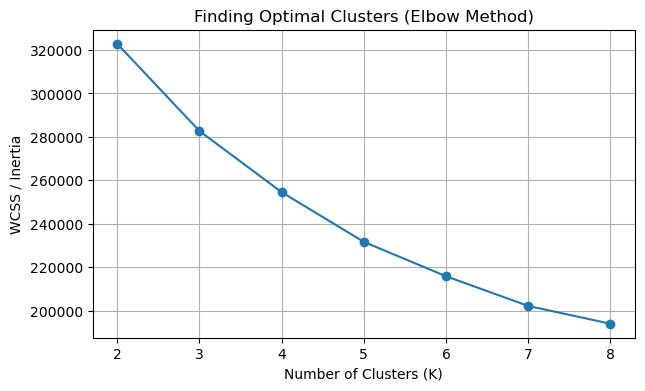

In [ ]:
import matplotlib.pyplot as plt

# 1. Compress features using PCA function
pca_data, pca_model = run_pca(customer_info_scaled[feature_cols])
print(f"1. Dimensionality Reduction: Features compressed to {pca_model.n_components_} PCA components.")

# 2. Extract clustering performance metrics
k_range, wcss, silhouette = get_clustering_metrics(pca_data)

# 3. Generate the Elbow curve plot 
plt.figure(figsize=(7, 4))
plt.plot(k_range, wcss, 'o-')
plt.title('Finding Optimal Clusters (Elbow Method)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.grid(True)
plt.show()



The plot above displays the relationship between the number of clusters ($K$) and the **Within-Cluster Sum of Squares (WCSS)**. 

### Interpretation:
* **The Slope Change:** We observe a sharp decline in WCSS as we move from 2 to 4 clusters.
* **The Elbow Point:** The "elbow" or inflection point is most visible at **$K = 5$**. At this point, the rate of improvement in WCSS begins to level off significantly.
* **Selection:** Choosing $K = 5$ provides a balanced model that captures the primary segments in our data without over-partitioning the customer base into redundant groups.

## 3. Final Results and Export
With $K = 5$ identified as the optimal cluster count, the final model has been applied to the PCA-transformed data. 


In [ ]:
# 4. Generate final cluster assignments 
final_df = apply_final_clustering(pca_data, customer_info_processed, k=5)

# 5. save submission CSV
submission = final_df[['customer_id', 'cluster']]
submission.to_csv('proposed_clusters.csv', index=False)

print(f"\n 'proposed_clusters.csv' successfully generated with {len(submission)} customer assignments.")


 'proposed_clusters.csv' successfully generated with 33038 customer assignments.


### Deliverables
* **Cluster Assignments:** Each customer has been assigned a unique segment ID (0-4).
* **Export:** The results have been saved to **`proposed_clusters.csv`**, containing the required `customer_id` and `cluster` columns for final submission and evaluation.

## 4. Customer Segment Profiling & Interpretation

With our final $K=5$ KMeans model successfully applied, we map the cluster labels back to our original, unscaled dataset. 
This allows us to calculate the average values of our real-world features (such as age, income, and spending metrics) for each distinct group.

#### Objective
By aggregating the data by cluster, we can move past abstract cluster numbers ($0, 1, 2, 3, 4$) and define concrete customer personas based on their behavioral and demographic patterns.

In [ ]:
# 1. Identify all numeric columns to average out (excluding IDs)
numeric_cols = final_df.select_dtypes(include=['number']).columns
if 'customer_id' in numeric_cols:
    numeric_cols = numeric_cols.drop('customer_id')

# 2. Calculate the average metrics for each of 5 clusters
cluster_profiles = final_df.groupby('cluster')[numeric_cols].mean()

# 3. Display the profiling table beautifully
print("📊 CUSTOMER SEGMENT PROFILES (MEAN VALUES):")
display(cluster_profiles.round(2))

# 4. Print out the size of each cluster to see group distributions
print("\n👥 CUSTOMER COUNT PER CLUSTER:")
print(final_df['cluster'].value_counts().sort_index())

📊 CUSTOMER SEGMENT PROFILES (MEAN VALUES):


,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,...,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,total_spend,age,has_loyalty_card,cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.48,0.25,0.32,1.03,1.49,8625.54,6737.01,17.40,193.33,543.46,...,273.98,704.06,302.01,107.14,0.26,2017.53,23629.81,55.18,0.47,0.0
1,0.51,1.03,0.89,0.69,3.36,11460.28,1443.03,12.37,1718.79,507.32,...,1289.33,176.97,333.99,103.26,0.12,2015.61,17474.08,57.06,0.58,1.0
2,0.49,0.91,0.64,0.99,3.29,12484.94,1042.86,12.05,430.17,280.93,...,579.39,189.03,328.15,117.75,0.44,2015.90,16918.88,51.34,0.59,2.0
3,0.51,1.01,1.01,1.05,3.69,30258.71,3291.47,12.77,430.39,662.99,...,1094.22,318.36,363.22,244.83,0.35,2012.84,43286.31,58.37,0.74,3.0
4,0.51,3.72,2.83,0.93,3.19,24380.16,4965.38,10.12,830.99,810.02,...,909.19,401.17,358.65,302.60,0.21,2013.30,37295.11,56.83,0.67,4.0



👥 CUSTOMER COUNT PER CLUSTER:
cluster
0     3538
1     7219
2    14316
3     5203
4     2762
Name: count, dtype: int64
